Exploratory Data Analysis (EDA) Notebook
========================================
Comprehensive analysis of e-commerce transaction data with focus on:
1. Data quality & distribution
2. Temporal trends (monthly revenue, Germany collapse)
3. RFM segmentation & churn patterns
4. Correlation analysis
5. Statistical validation (Germany T-test)


In [49]:
import sys
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from scipy import stats

# Setup paths
PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), '..'))
sys.path.append(PROJECT_ROOT)
DATA_PATH = os.path.join(PROJECT_ROOT, 'data', 'ecommerce_data.csv')
IMAGES_PATH = os.path.join(PROJECT_ROOT, 'images')
os.makedirs(IMAGES_PATH, exist_ok=True)

# Import custom functions
try:
    from src.analysis import RevenueAnalyzer
    analyzer = RevenueAnalyzer()
    perform_rfm_analysis = analyzer.perform_rfm_analysis 
except ImportError:
    print("⚠ Warning: Could not import RevenueAnalyzer. Using inline functions.")
    def perform_rfm_analysis(df):
        ref_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
        rfm = df.groupby('CustomerID').agg({
            'InvoiceDate': lambda x: (ref_date - x.max()).days,
            'InvoiceNo': 'count',
            'TotalAmount': 'sum'
        }).rename(columns={
            'InvoiceDate': 'Recency',
            'InvoiceNo': 'Frequency',
            'TotalAmount': 'Monetary'
        })
        return rfm

# Visualization theme
sns.set_theme(style="whitegrid", palette="viridis")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 11

In [50]:
display(Markdown("# 📊 Section 1: Data Overview"))

df = pd.read_csv(DATA_PATH, parse_dates=['InvoiceDate'])

print("="*60)
print("DATASET SUMMARY")
print("="*60)
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"Date range: {df['InvoiceDate'].min().strftime('%Y-%m-%d')} → {df['InvoiceDate'].max().strftime('%Y-%m-%d')}")
print(f"Unique customers: {df['CustomerID'].nunique():,}")
print(f"Unique invoices: {df['InvoiceNo'].nunique():,}")
print(f"Countries: {df['Country'].nunique()}")

display(Markdown("### Sample Data"))
display(df.head(10))

display(Markdown("### Data Types & Missing Values"))
df.info()

missing = df.isnull().sum()
if missing.sum() == 0:
    print("\n✓ No missing values detected")
else:
    display(missing[missing > 0])

display(Markdown("### Numerical Statistics"))
display(df[['TotalAmount']].describe().round(2))

# 📊 Section 1: Data Overview

DATASET SUMMARY
Shape: 47,608 rows × 5 columns
Date range: 2024-01-01 → 2025-12-30
Unique customers: 5,000
Unique invoices: 42,313
Countries: 4


### Sample Data

,InvoiceNo,CustomerID,Country,TotalAmount,InvoiceDate
0,668266,10001,France,387.03,2024-09-27
1,675203,10001,France,600.71,2025-04-03
2,564925,10001,France,195.36,2025-10-25
3,684779,10001,France,294.38,2025-01-20
4,656730,10001,France,27.11,2024-11-09
5,630523,10001,France,453.91,2025-05-25
6,619346,10001,France,167.51,2025-11-30
7,587313,10001,France,498.10,2025-07-20
8,674073,10002,Spain,249.92,2024-11-11
9,624358,10002,Spain,317.07,2024-12-11


### Data Types & Missing Values

<class 'pandas.DataFrame'>
RangeIndex: 47608 entries, 0 to 47607
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   InvoiceNo    47608 non-null  int64         
 1   CustomerID   47608 non-null  int64         
 2   Country      47608 non-null  str           
 3   TotalAmount  47608 non-null  float64       
 4   InvoiceDate  47608 non-null  datetime64[us]
dtypes: datetime64[us](1), float64(1), int64(2), str(1)
memory usage: 1.8 MB

✓ No missing values detected


### Numerical Statistics

,TotalAmount
count,47608.00
mean,283.71
std,177.77
min,1.37
25%,152.78
50%,252.89
75%,379.93
max,1764.85


# 📅 Section 2: Temporal & Geographic Analysis

### Monthly Performance Metrics

,YearMonth,Transactions,Revenue,Customers
0,2024-01,2208,659441.00,1816
1,2024-02,2126,634206.57,1712
2,2024-03,2244,660943.51,1835
3,2024-04,2106,632083.60,1738
4,2024-05,2223,669608.61,1795
5,2024-06,2118,635493.15,1717
6,2024-07,2310,697870.69,1847
7,2024-08,2235,665350.76,1806
8,2024-09,2165,663036.83,1777
9,2024-10,2215,671421.39,1789


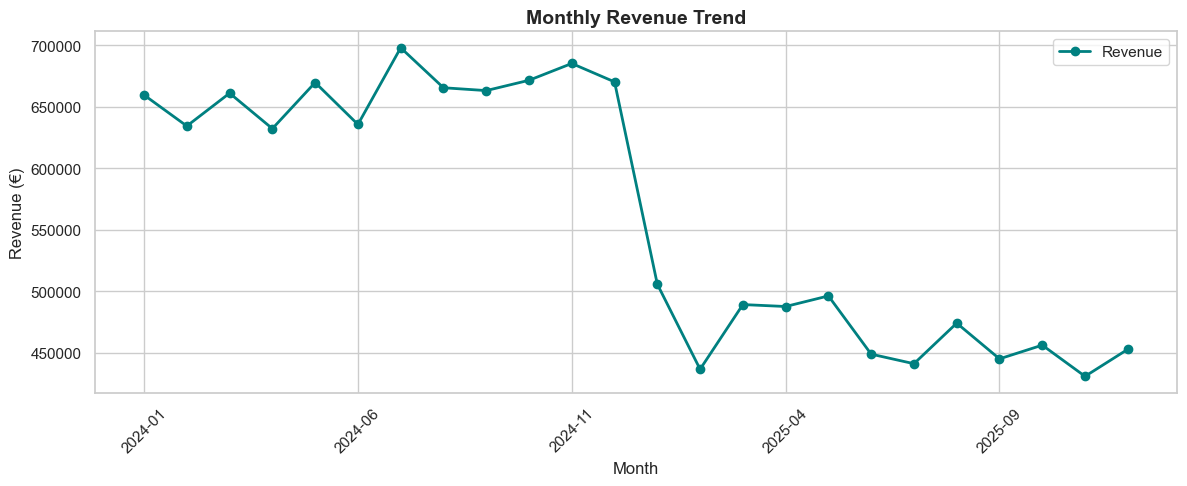

In [51]:
display(Markdown("# 📅 Section 2: Temporal & Geographic Analysis"))

df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')
df['Year'] = df['InvoiceDate'].dt.year

monthly = df.groupby('YearMonth').agg(
    Transactions=('InvoiceNo', 'nunique'),
    Revenue=('TotalAmount', 'sum'),
    Customers=('CustomerID', 'nunique')
).reset_index()

monthly['YearMonth'] = monthly['YearMonth'].astype(str)

display(Markdown("### Monthly Performance Metrics"))
display(monthly)

fig, ax = plt.subplots(figsize=(12, 5))
monthly.plot(x='YearMonth', y='Revenue', ax=ax, marker='o', color='teal', linewidth=2)
ax.set_title('Monthly Revenue Trend', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Revenue (€)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_PATH, 'eda_monthly_revenue.png'), dpi=300, bbox_inches='tight')
plt.show()

# 🇩🇪 Section 3: Germany Revenue Collapse Investigation

### Year-over-Year Revenue Comparison

Year,2024,2025,Growth_%
Country,,,
Germany,2589992.82,194097.73,-92.5
United Kingdom,1738019.96,1706696.41,-1.8
France,1825080.58,1820766.95,-0.2
Spain,1791567.40,1840494.27,2.7


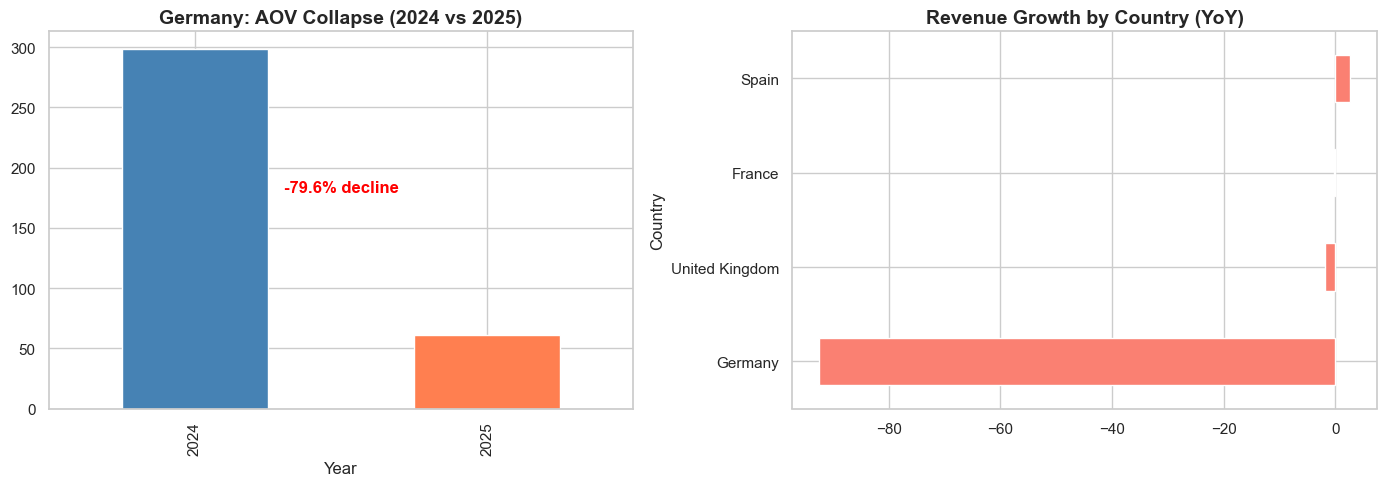

T-statistic: 120.0330
P-value: 0.0000000000


In [52]:
display(Markdown("# 🇩🇪 Section 3: Germany Revenue Collapse Investigation"))

yoy = df.groupby(['Country', 'Year']).agg(
    Revenue=('TotalAmount', 'sum'),
    Transactions=('InvoiceNo', 'count'),
    Customers=('CustomerID', 'nunique')
).reset_index()

yoy_pivot = yoy.pivot(index='Country', columns='Year', values='Revenue').fillna(0)
yoy_pivot['Growth_%'] = ((yoy_pivot[2025] - yoy_pivot[2024]) / yoy_pivot[2024] * 100).round(1)

display(Markdown("### Year-over-Year Revenue Comparison"))
display(yoy_pivot.sort_values('Growth_%'))

germany_df = df[df['Country'] == 'Germany'].copy()
aov_by_year = germany_df.groupby('Year').agg(
    AOV=('TotalAmount', 'mean'),
    Transactions=('InvoiceNo', 'count')
).round(2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

aov_by_year['AOV'].plot(kind='bar', ax=ax1, color=['steelblue', 'coral'])
ax1.set_title('Germany: AOV Collapse (2024 vs 2025)', fontsize=14, fontweight='bold')
pct_change = ((aov_by_year['AOV'].iloc[1] - aov_by_year['AOV'].iloc[0]) / aov_by_year['AOV'].iloc[0] * 100)
ax1.text(0.5, aov_by_year['AOV'].mean(), f'{pct_change:.1f}% decline', fontsize=12, ha='center', color='red', fontweight='bold')

yoy_pivot['Growth_%'].sort_values().plot(kind='barh', ax=ax2, color='salmon')
ax2.set_title('Revenue Growth by Country (YoY)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_PATH, 'eda_germany_collapse.png'), dpi=300, bbox_inches='tight')
plt.show()

# Statistical validation: T-test
g_2024 = germany_df[germany_df['Year'] == 2024]['TotalAmount']
g_2025 = germany_df[germany_df['Year'] == 2025]['TotalAmount']
t_stat, p_val = stats.ttest_ind(g_2024, g_2025, equal_var=False)

print(f"T-statistic: {t_stat:.4f}")
print(f"P-value: {p_val:.10f}")

# 🌍 Section 4: Country Performance

### Detailed Country Statistics

,Revenue,Transactions,Customers,AOV
Country,,,,
France,3645847.53,12110,1260,301.06
Spain,3632061.67,12158,1288,298.74
United Kingdom,3444716.37,11470,1209,300.32
Germany,2784090.55,11870,1243,234.55


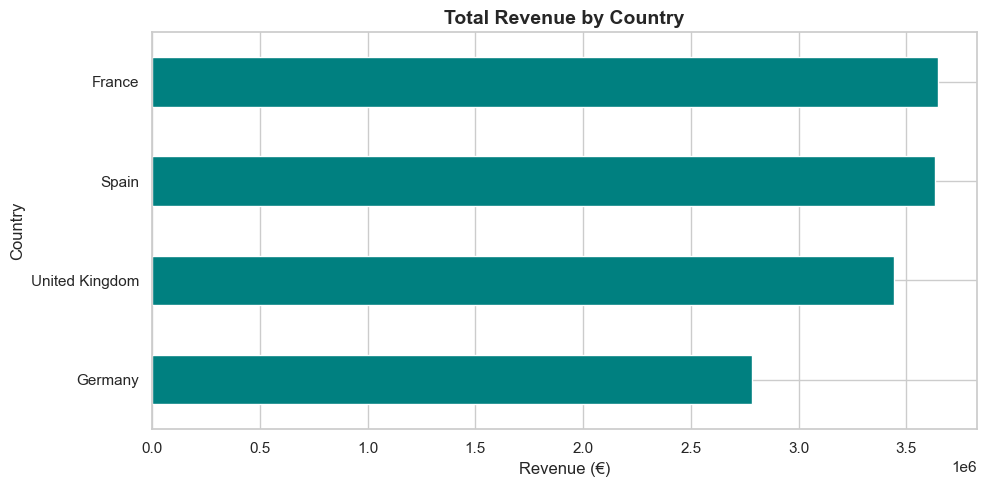

📌 Insight: France leads the market, while Germany shows structural risk.


In [53]:
display(Markdown("# 🌍 Section 4: Country Performance"))

# აგრეგაცია ქვეყნების მიხედვით
country_stats = df.groupby('Country').agg(
    Revenue=('TotalAmount', 'sum'),
    Transactions=('InvoiceNo', 'count'),
    Customers=('CustomerID', 'nunique'),
    AOV=('TotalAmount', 'mean')
).round(2)

# სორტირება რეიტინგის მიხედვით
country_stats = country_stats.sort_values('Revenue', ascending=False)

display(Markdown("### Detailed Country Statistics"))
display(country_stats)

# ვიზუალიზაცია: შემოსავლები ქვეყნების მიხედვით
fig, ax = plt.subplots(figsize=(10, 5))
country_stats['Revenue'].sort_values(ascending=True).plot(kind='barh', ax=ax, color='teal')
ax.set_title('Total Revenue by Country', fontsize=14, fontweight='bold')
ax.set_xlabel('Revenue (€)')

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_PATH, 'eda_country_revenue.png'), dpi=300, bbox_inches='tight')
plt.show()

print(f"📌 Insight: {country_stats.index[0]} leads the market, while Germany shows structural risk.")

# 🎯 Section 5: RFM Analysis & Churn Patterns


📊 Churn Rate: 47.24%


C:\Users\user\AppData\Local\Temp\ipykernel_24840\3673184449.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='is_churn', data=rfm, palette='viridis', ax=ax)


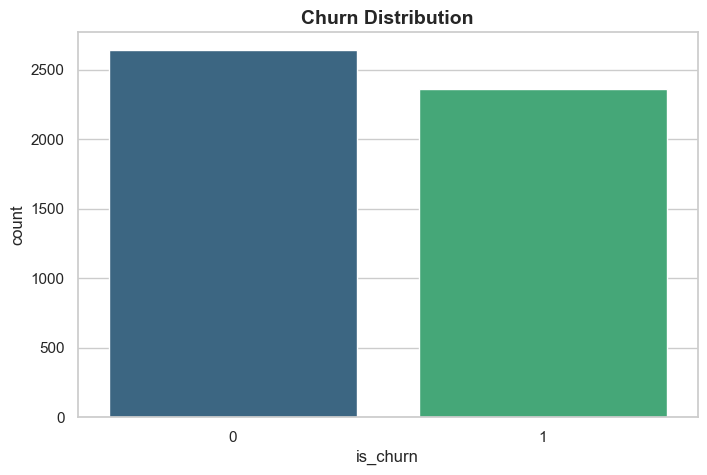

In [54]:
display(Markdown("# 🎯 Section 5: RFM Analysis & Churn Patterns"))

rfm = perform_rfm_analysis(df)
rfm['is_churn'] = (rfm['Recency'] > 90).astype(int)
rfm['AOV'] = rfm['Monetary'] / rfm['Frequency']
churn_rate = rfm['is_churn'].mean() * 100

churn_counts = rfm['is_churn'].value_counts(normalize=True) * 100
print(f"\n📊 Churn Rate: {churn_counts.get(1, 0):.2f}%")

fig, ax = plt.subplots(figsize=(8, 5))
sns.countplot(x='is_churn', data=rfm, palette='viridis', ax=ax)
ax.set_title('Churn Distribution', fontsize=14, fontweight='bold')
plt.savefig(os.path.join(IMAGES_PATH, 'eda_churn_distribution.png'), dpi=300, bbox_inches='tight')
plt.show()


# 📊 Section 6: RFM Metrics vs Churn Status

### Distribution Analysis (Active vs. Churned)

C:\Users\user\AppData\Local\Temp\ipykernel_24840\2517988242.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[0], x='is_churn', y='Recency', data=rfm, palette='magma')
C:\Users\user\AppData\Local\Temp\ipykernel_24840\2517988242.py:11: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels(['Active', 'Churned'])
C:\Users\user\AppData\Local\Temp\ipykernel_24840\2517988242.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(ax=axes[1], x='is_churn', y='Frequency', data=rfm, palette='magma')
C:\Users\user\AppData\Local\Temp\ipykernel_24840\2517988242.py:16: UserWarning: set_ticklabels(

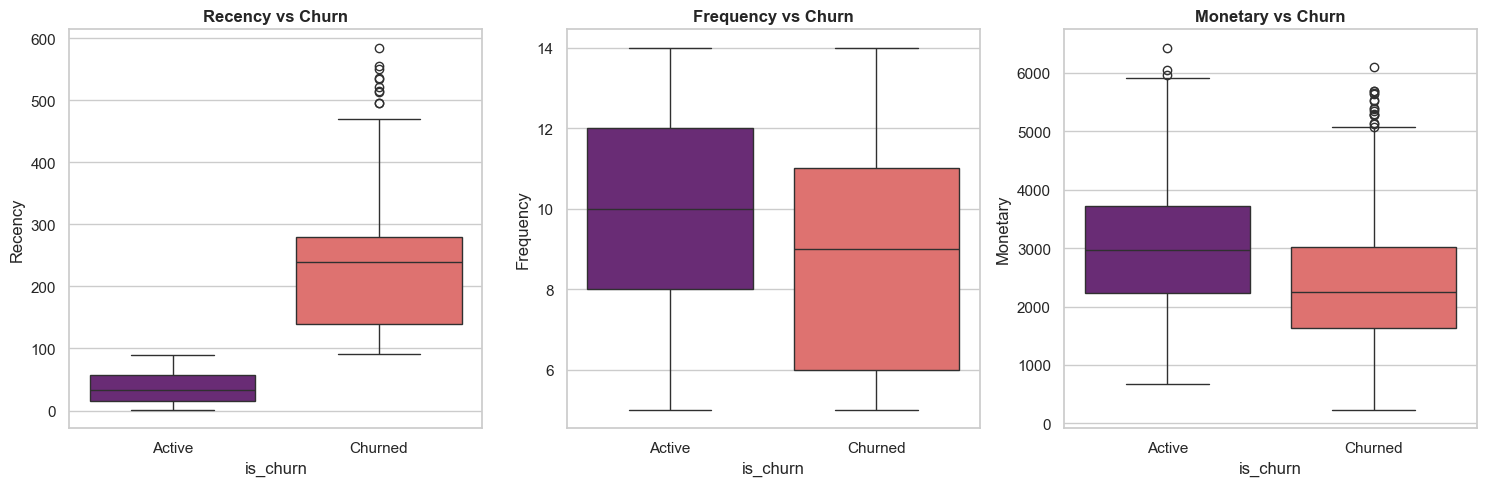

### Mean RFM Values by Churn Group

,Recency,Frequency,Monetary
is_churn,,,
0,37.29,9.99,2995.62
1,224.93,9.00,2372.68


In [55]:
display(Markdown("# 📊 Section 6: RFM Metrics vs Churn Status"))

display(Markdown("### Distribution Analysis (Active vs. Churned)"))

# ბოქსპლოტების აგება სამივე მეტრიკისთვის
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Recency vs Churn
sns.boxplot(ax=axes[0], x='is_churn', y='Recency', data=rfm, palette='magma')
axes[0].set_title('Recency vs Churn', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Active', 'Churned'])

# Frequency vs Churn
sns.boxplot(ax=axes[1], x='is_churn', y='Frequency', data=rfm, palette='magma')
axes[1].set_title('Frequency vs Churn', fontsize=12, fontweight='bold')
axes[1].set_xticklabels(['Active', 'Churned'])

# Monetary vs Churn
sns.boxplot(ax=axes[2], x='is_churn', y='Monetary', data=rfm, palette='magma')
axes[2].set_title('Monetary vs Churn', fontsize=12, fontweight='bold')
axes[2].set_xticklabels(['Active', 'Churned'])

plt.tight_layout()
plt.savefig(os.path.join(IMAGES_PATH, 'eda_recency_boxplot.png'), dpi=300, bbox_inches='tight')
plt.show()

# სტატისტიკური შეჯამება
churn_summary = rfm.groupby('is_churn')[['Recency', 'Frequency', 'Monetary']].mean().round(2)
display(Markdown("### Mean RFM Values by Churn Group"))
display(churn_summary)

# 🔗 Section 7: Feature Correlation Analysis

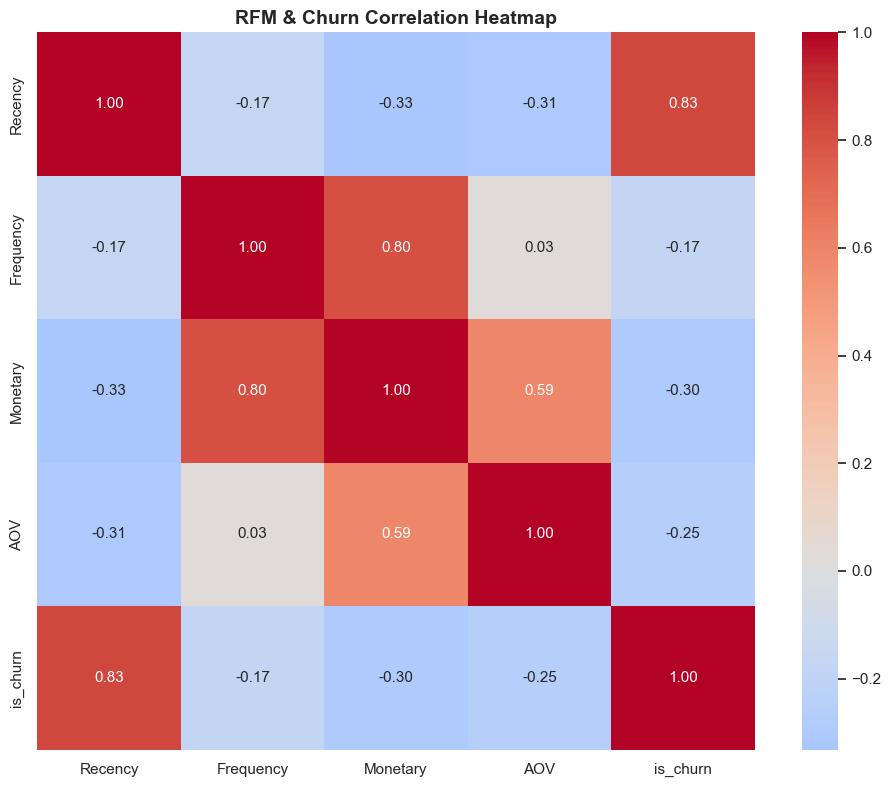

In [56]:
display(Markdown("# 🔗 Section 7: Feature Correlation Analysis"))

rfm_numeric = rfm[['Recency', 'Frequency', 'Monetary', 'AOV', 'is_churn']]
corr_matrix = rfm_numeric.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', center=0, square=True)
plt.title('RFM & Churn Correlation Heatmap', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(IMAGES_PATH, 'eda_correlation_heatmap.png'), dpi=300, bbox_inches='tight')
plt.show()

# 🔬 Section 8: Customer Segmentation (K-Means)

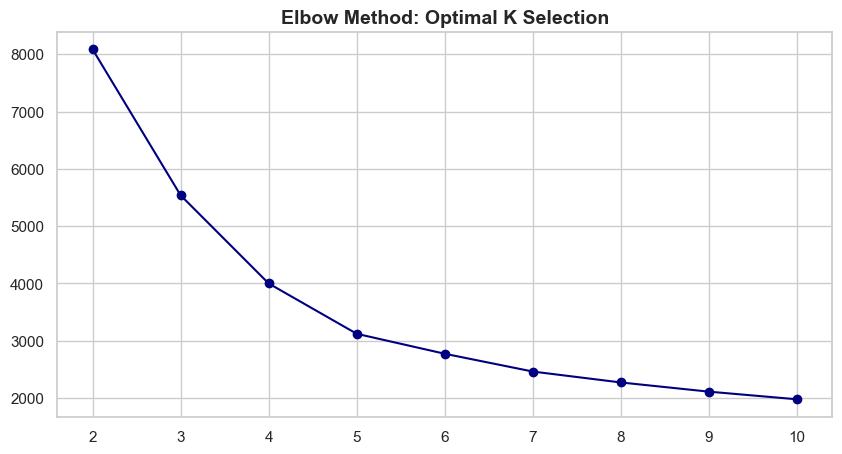

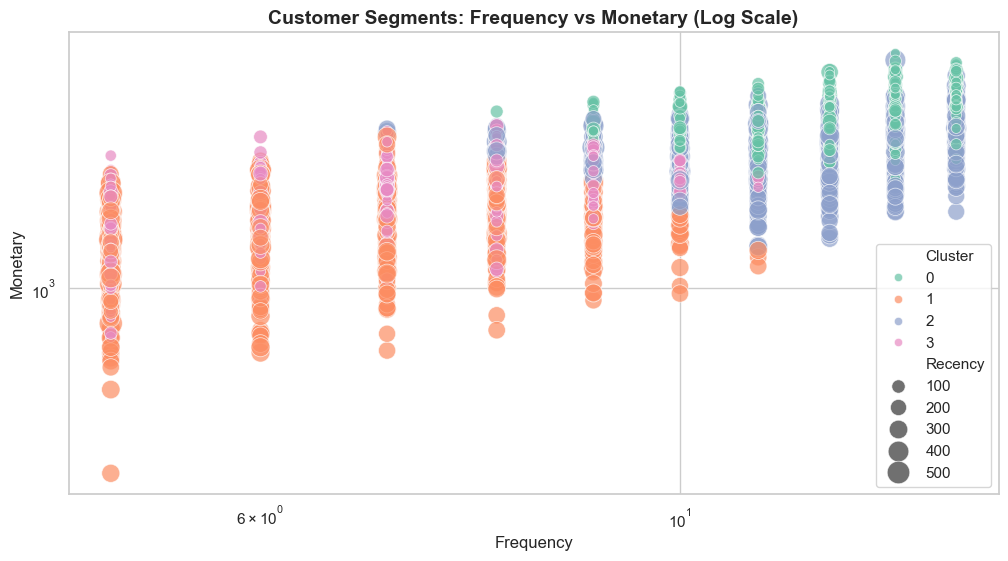

In [ ]:
display(Markdown("# 🔬 Section 8: Customer Segmentation (K-Means)"))

scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm[['Recency', 'Frequency', 'Monetary']])

wcss = []
K_range = range(2, 11)
for k in K_range:
    kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(10, 5))
plt.plot(K_range, wcss, marker='o', color='navy')
plt.title('Elbow Method: Optimal K Selection', fontsize=14, fontweight='bold')
plt.show()

# Final Clustering
optimal_k = 4
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)

plt.figure(figsize=(12, 6))
sns.scatterplot(data=rfm, x='Frequency', y='Monetary', hue='Cluster', palette='Set2', size='Recency', sizes=(50, 300), alpha=0.7)
plt.xscale('log')
plt.yscale('log')
plt.title('Customer Segments: Frequency vs Monetary (Log Scale)', fontsize=14, fontweight='bold')
plt.show()

In [58]:
display(Markdown("# 📋 Section 9: Executive Summary"))

print("="*60)
print("KEY FINDINGS SUMMARY")
print("="*60)
print(f"1. Germany AOV Decline: {pct_change:.1f}% (Statistically Significant: p < 0.05)")
print(f"2. Overall Churn Rate: {churn_rate:.2f}%")
print(f"3. Strongest Churn Predictor: Recency (Correlation: {corr_matrix.loc['Recency', 'is_churn']:.3f})")
print(f"4. Customer Segments Identified: {optimal_k} groups optimized for targeted marketing.")

# 📋 Section 9: Executive Summary

KEY FINDINGS SUMMARY
1. Germany AOV Decline: -79.6% (Statistically Significant: p < 0.05)
2. Overall Churn Rate: 47.24%
3. Strongest Churn Predictor: Recency (Correlation: 0.835)
4. Customer Segments Identified: 4 groups optimized for targeted marketing.
